In [1]:
print("Loading packages")
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import tifffile as tiff

from pyvis.network import Network

from skimage.morphology import skeletonize
from skimage.util import invert
from skimage import io

from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle


from skeleton_model import form_networks_all

Loading packages


In [8]:
def visualise_image(image,dists,nodes,adj):
    fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(80, 40), sharex=True, sharey=True)#,gridspec_kw={'width_ratios': [len(image[0]), len(image)]})
    patches = []
    for i in nodes.index:
        x,y,weight = nodes[["x","y","weight"]].loc[i]
        circle = Circle((x, y), 1+weight/40)
        patches.append(circle)
    for i in adj:
        for j in adj:
            dist = adj.loc[i,j]
            if dist>0:
                x1,y1=nodes[["x","y"]].loc[i]
                x2,y2=nodes[["x","y"]].loc[j]
                ax[0].plot([x1,x2],[y1,y2])
    ax[1].imshow(image, cmap=plt.cm.gray)
    p = PatchCollection(patches, alpha=0.4)
    ax[1].add_collection(p)

    ax[0].imshow(dists, cmap=plt.cm.gray)
    p = PatchCollection(patches, alpha=0.4)
    ax[0].add_collection(p)
    #fig.set_figheight(len(image)/100)
    #fig.set_figwidth(len(image[0])/10)
    #fig.set_size_inches(len(image)/10,len(image[0])/10)

    plt.show()

In [10]:
def gen_networkx_graph(nodes,adj):
    G = nx.Graph()
    for i in nodes.index:
        node = nodes.loc[i]
        #G.add_node(i)#,weight=node["weight"])
        G.add_nodes_from([(i, {"x": int(node["x"]), "y": int(node["y"]), "weight":float(node["weight"])})])
    for i in adj.index:
        for j in adj.columns:
            weight = adj.loc[i,j]
            if weight>0:
                G.add_edge(i,j)#,weight=weight)
    #nx.draw(G, with_labels=True)
    return G

In [11]:
def display_network(net,name):
    #nx.draw(net,with_labels=True)

    new_net = Network(height="750px", width="100%", bgcolor="#1F1F1F", font_color="white")#,notebook=True)
    new_net.toggle_physics(False) #displays the network
    new_net.from_nx(net)
    
    #[nx.set_node_attributes(net,)]
    #new_net.save_graph(f"{name}")
    new_net.show(f"{name}")#,notebook=True)

In [12]:
def gen_pyvis_graph(nodes,adj,name):
    G = Network(height="750px", width="100%", bgcolor="#1F1F1F", font_color="white",notebook=True)
    G.toggle_physics(False)
    for i in nodes.index:
        node = nodes.loc[i]
        G.add_node(i,label=i,size=float(node["weight"])/50,x=int(node["x"]),y=int(node["y"]))
        #G.add_nodes_from([(i, {"x": int(node["x"]), "y": int(node["y"]), "weight":float(node["weight"])})])
    for i in adj.index:
        for j in adj.columns:
            edge_weight = adj.loc[i,j]
            if edge_weight>0:
                G.add_edge(i,j,weight=float(edge_weight))
                if i==j:
                    print(f"edge between {i} and {j}")
    #nx.draw(G, with_labels=True)
    G.show(f"{name}")#,notebook=True)
    return G

In [ ]:
drug_name="mmp brendan"
conditions = ["control nuclei","10um nuclei","20um nuclei"]
conditions = ["10um","30um","50um"]

drug_name="mmp brendan2"
conditions = ["Control","10um","20um","30um"]

#spatial resolution: number of pixels per micron
#MAKE SURE this matches the ratio used in the skeleton.ijm macro!
pix_micron_ratio = 0.25

microns_per_pixel = 1/pix_micron_ratio

base=2 #intercept term
dist_propn=0.08 #multiplier term

path = f"data/skeleton/drugs/{drug_name}"

#Think the files are named incorrectly to load them at the moment
nodes_all_stages, adj_all_stages = form_networks_all(conditions,path,microns_per_pixel,base=base,dist_propn=dist_propn)


Stage is Control
Stage is 10um
Stage is 20um
Stage is 30um


In [3]:
print(nodes_all_stages[1])

[]


In [14]:
pickle.dump(nodes_all_stages,open(f"results/skeleton/nodes_list_{drug_name}.txt","wb"))
pickle.dump(adj_all_stages,open(f"results/skeleton/adj_list_{drug_name}.txt","wb"))

In [ ]:
def image_plot(image):
    #show skeleton
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(image,cmap=plt.cm.gray)
    ax.axis('off') 

    size = 1000
    x_min = 100
    y_min = 100
    x_max,y_max = x_min+size,y_min+size

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)

    plt.show()

: 

In [ ]:
def nodes_plot(image,nodes,adj,node_alpha=0.4,edge_alpha=1,im_alpha=1,edge_weights=False,node_weights=False):
    #show skeleton
    fig,ax=plt.subplots(figsize=(10,10))
    ax.imshow(image,cmap=plt.cm.gray,alpha=im_alpha)
    ax.axis('off') 

    size = 1000
    x_min = 100
    y_min = 100
    x_max,y_max = x_min+size,y_min+size



    #calculate nodes and edges
    patches = []
    for i in nodes.index:
        x,y,weight,type = nodes[["x","y","weight","type"]].loc[i]
        if x_min<=x<=x_max and y_min<=y<=y_max: #only plot the valid region
            if type == "junction": #colourings
                circle = Circle((x, y), 1+weight,color="#e2342c")
            else: 
                circle = Circle((x, y), 1+weight,color="#f2ad00")
            patches.append(circle)

            #text labelling
            if node_weights and int(weight)!=76 and int(weight)!=70 and int(weight)!=12: #hacky line to remove overlapping numbers
                ax.text(x, y, str(int(weight)), ha='center', va='center', fontsize=20, color='white',font="arial",weight="bold")
            
            
    p = PatchCollection(patches, alpha=node_alpha,match_original=True)
    ax.add_collection(p)


    #code for edges
    for i in adj:
        for j in adj:
            dist = adj.loc[i,j]
            if dist>0:
                x1,y1=nodes[["x","y"]].loc[i]
                x2,y2=nodes[["x","y"]].loc[j]
                if x_min<=x1<=x_max and y_min<=y1<=y_max:
                    ax.plot([x1,x2],[y1,y2],alpha=edge_alpha,linewidth=5)

                    #text labelling
                    av_x,av_y = (x1+x2)/2, (y1+y2)/2
                    if edge_weights and int(dist)!=4 and int(dist)!=244:
                        ax.text(av_x, av_y, str(int(dist)), ha='left', va='bottom', fontsize=20, color='white' ,font="arial",weight="bold")


    

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_max, y_min)

    plt.show()

: 

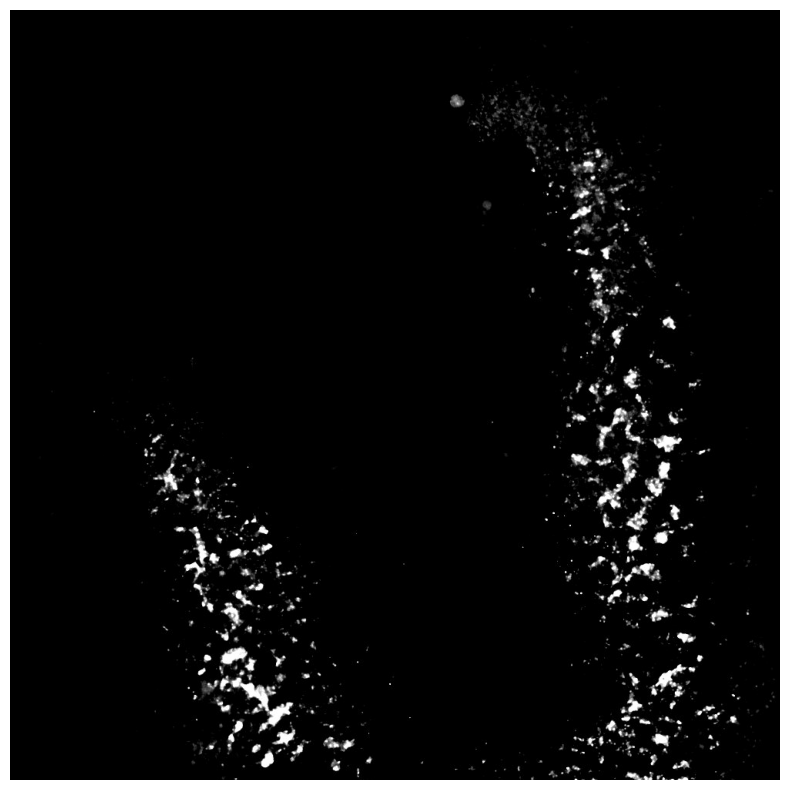

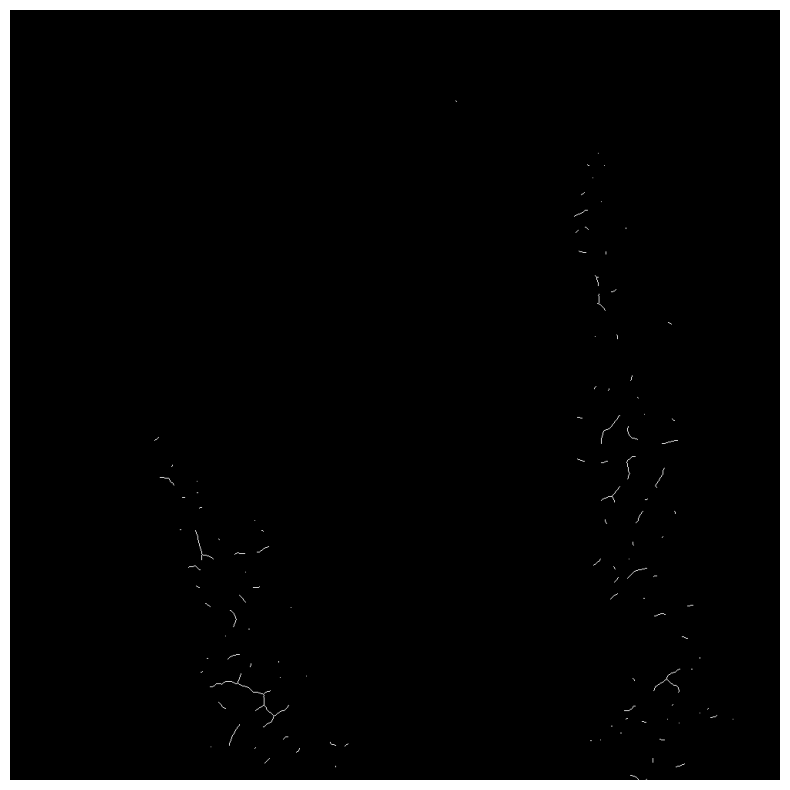

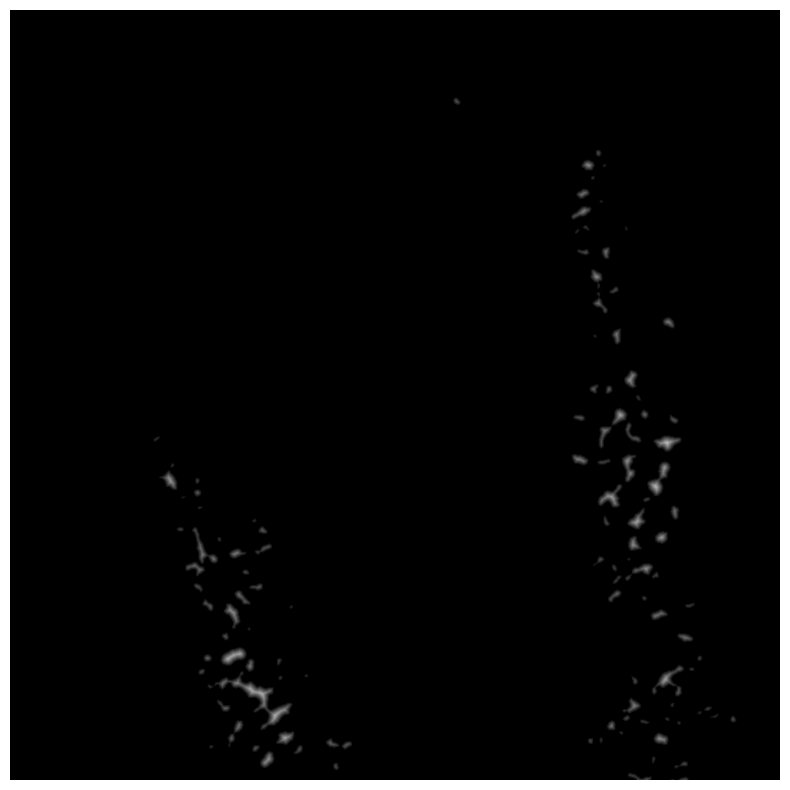

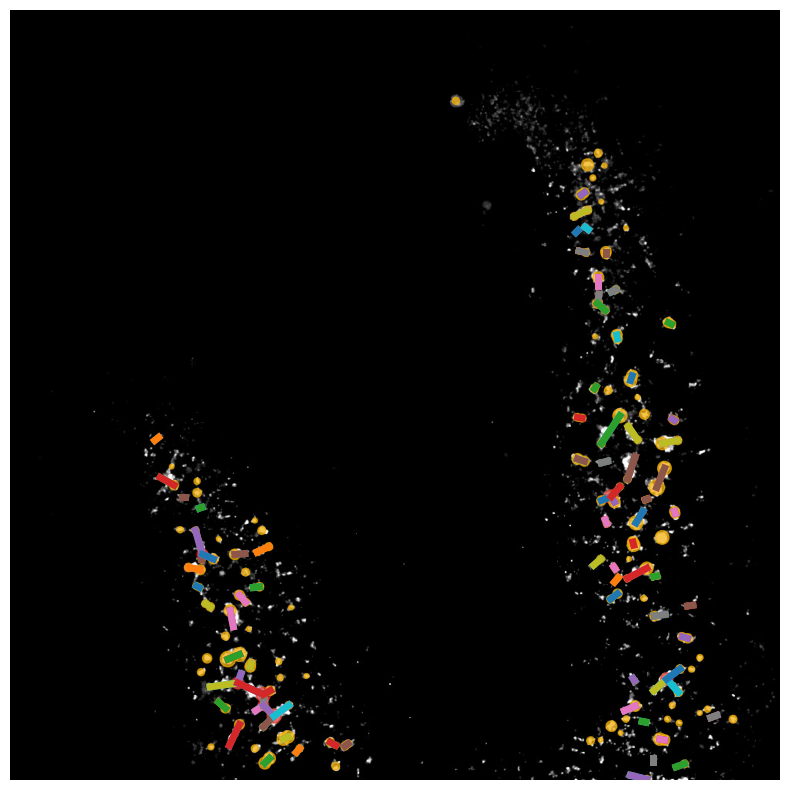

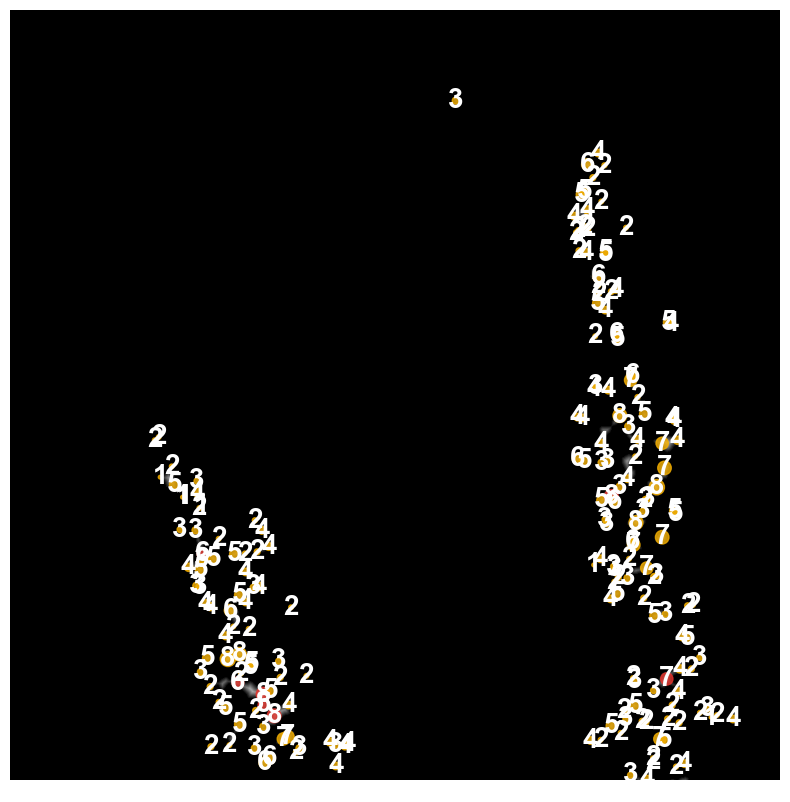

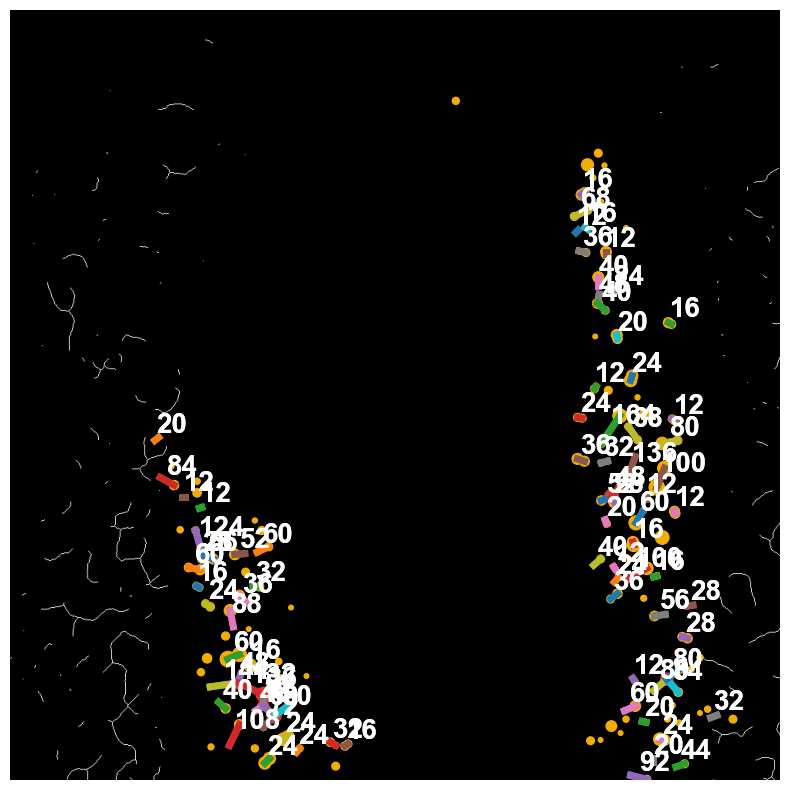

: 

In [ ]:
n=1
stage=4
nodes = nodes_all_stages[0][n-1]
adj = adj_all_stages[0][n-1]

original = cv2.imread(f'{path}n{n}_hh{stage}_plain_scaled.jpg')
skele = tiff.imread(f'{path}n{n}_hh{stage}_skeleton.tif')
dists = tiff.imread(f"{path}n{n}_hh{stage}_distmap.tif") 
black = cv2.imread(f"{path}black.jpg") 

image_plot(original)
image_plot(skele)
image_plot(dists)


#nodes_plot(skele,nodes,adj)
nodes_plot(original,nodes,adj,node_alpha=0.7)

nodes_plot(dists,nodes,adj,edge_alpha=0,node_alpha=0.8,node_weights=True)
nodes_plot(image,nodes,adj,node_alpha=1,edge_weights=True)